# MES VWAP deviation-band mean-reversion, 15-minute bars (Tradovate exchange)

A structurally different edge source from every strategy tested so far in this
pipeline -- Donchian/Keltner/SuperTrend/Pullback-to-MA are all trend-following
(bet the move continues); this one is a pure intraday fade: enter against an
extreme deviation from session VWAP, expecting reversion back toward it.

**Mechanism** (`VwapMeanReversionStrategy`): `Indicators.vwap_session` gives a
session-reset VWAP and its volume-weighted standard deviation. Enter long when
price touches `entry_std` deviations below VWAP (short when `entry_std` above),
exit once price reverts to within `exit_std` deviations of VWAP (0.0 = exit at
VWAP itself), or a fixed-percent stop-loss if the deviation keeps extending
instead of reverting. `direction=both` from the start, unlike this pipeline's
trend-following strategies -- fading an intraday extreme is a different bet
than fighting a multi-day trend, so there's no a priori reason to expect the
same long-only bias here.

15-minute bars, this pipeline's usual default. VWAP resets every session, so
this is inherently a same-day signal -- 15-minute bars give ~78 bars/session
to work with, coarser than a typical intraday mean-reversion setup would use,
but consistent with every other notebook in this pipeline and a reasonable
starting point before considering finer resolution.

Same discipline as every other notebook in this pipeline: naive full-history
grid -> best-combo detailed report -> 75/25 holdout -> (if promising)
walk-forward, on real Databento MES 1-minute data resampled to 15-minute bars.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import StrategyDirection, VwapMeanReversionStrategy
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "MES"
SYMBOL = "MES/USD"
INTERVAL = 15
UNIT_OF_TIME = "minute"

mes_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(mes_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 168278  span: 2019-05-05 22:14:59.999000 -> 2026-07-12 23:14:59.999000


## Grid search: entry_std x sl_percent, direction=both

`exit_std=0.0` (exit at VWAP itself) and `min_bars_since_session_start=3`
fixed for this first pass -- same fixed-extras-while-gridding-the-core-two-
parameters convention as every other notebook in this pipeline.


In [3]:
ENTRY_STD_CANDIDATES = [1.5, 2.0, 2.5, 3.0]
SL_PERCENT_CANDIDATES = [0.005, 0.01, 0.015, 0.02]
EXIT_STD = 0.0
DEPOSIT_USD = 50_000


def run_vwap_mr_backtest(ohlc_slice: pd.DataFrame, entry_std: float, sl_percent: float, key: str,
                          direction: StrategyDirection = StrategyDirection.both):
    vwap, std = Indicators.vwap_session(ohlc_slice)

    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_slice)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="vwap", df=vwap)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="vwap_std", df=std)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=VwapMeanReversionStrategy(
            key=key, market=market, symbol=SYMBOL, direction=direction,
            vwap_indicator_key="vwap", vwap_std_indicator_key="vwap_std",
            entry_std=entry_std, exit_std=EXIT_STD, sl_percent=sl_percent, sl_enabled=True,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


grid_rows = []
grid_backtests = {}
_t0 = time.time()
for entry_std in ENTRY_STD_CANDIDATES:
    for sl_percent in SL_PERCENT_CANDIDATES:
        bt, drawdown_mw = run_vwap_mr_backtest(ohlc, entry_std, sl_percent, key=f"VWAPMR_{entry_std}_{sl_percent}")
        summary = bt.reporter.summary["algo"]
        total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
        grid_backtests[(entry_std, sl_percent)] = (bt, drawdown_mw)
        grid_rows.append({
            "entry_std": entry_std, "sl_percent": sl_percent,
            "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
            "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
            "trades_per_year": round(summary["closed_trades"] / 7.2, 1), "win_rate_percent": summary["win_rate_percent"],
            "profit_factor": summary["profit_factor"], "r_multiple_expectancy": summary["r_multiple_expectancy"],
            "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
            "total_fees_usd": total_fees, "account_failed": drawdown_mw.account_failed,
        })
    print(f"entry_std={entry_std} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid_results = pd.DataFrame(grid_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print("\ngrid done in " + f"{time.time() - _t0:.0f}s\n")
print(grid_results.to_string())


entry_std=1.5 done, 199s elapsed


entry_std=2.0 done, 344s elapsed


entry_std=2.5 done, 510s elapsed


entry_std=3.0 done, 612s elapsed



grid done in 612s

    entry_std  sl_percent  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0         1.5       0.015          -49.677320     -1.165149              -50.1390         2290.0            318.1         73.493450       0.918312              -0.007477              0.786255          -7.483664         7694.96            True
1         2.0       0.020          -48.649174     -1.240347              -50.0608         1741.0            241.8         75.244113       1.185354               0.011085              0.728911         -10.417099         6189.82            True
2         3.0       0.020          -41.330032     -1.245650              -42.2755         3716.0            516.1         83.100108       2.026908               0.027060              0.809623          -4.552751         7398.30           False
3       

### Heatmaps: Sharpe ratio and net return across (entry_std, sl_percent)


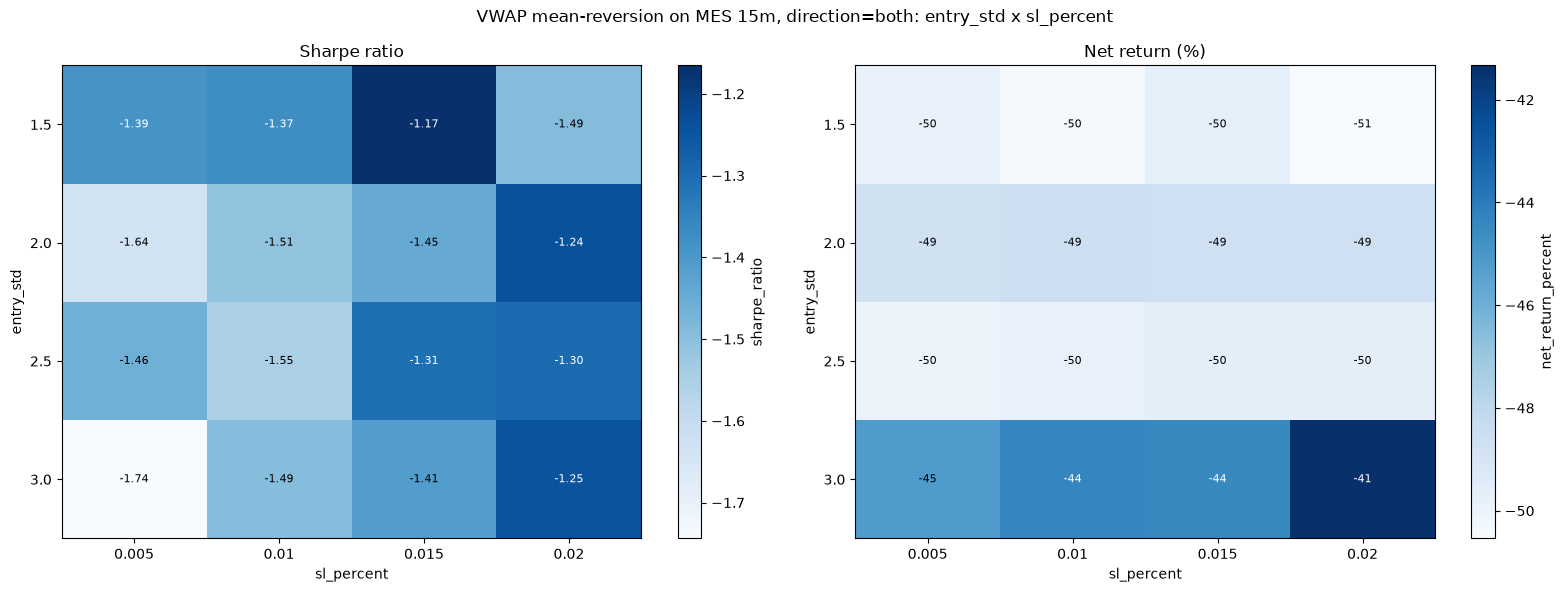

In [4]:
def _plot_heatmap(ax, pivot: pd.DataFrame, title: str, fmt: str):
    values = pivot.values.astype(float)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    span = vmax - vmin if vmax > vmin else 1.0
    im = ax.imshow(values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), labels=[str(i) for i in pivot.index])
    ax.set_xlabel("sl_percent")
    ax.set_ylabel("entry_std")
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            normalized = (val - vmin) / span
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8,
                    color="white" if normalized > 0.6 else "black")
    return im


sharpe_pivot = grid_results.pivot(index="entry_std", columns="sl_percent", values="sharpe_ratio")
return_pivot = grid_results.pivot(index="entry_std", columns="sl_percent", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot, "Sharpe ratio", ".2f")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot, "Net return (%)", ".0f")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle("VWAP mean-reversion on MES 15m, direction=both: entry_std x sl_percent")
fig.tight_layout()
plt.show()


## Detailed report for the best combo

Full HTML summary (year-by-year split) and equity/drawdown charts for the
best (entry_std, sl_percent) combo from the grid above.


Best combo: entry_std=1.5, sl_percent=0.015
Candles Processed: 168277
Account failed (drawdown breach): True


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,-1.1651,-6.2873,-1.4192,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6392,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,-1.5342,-6.3947,-1.9459,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.9137,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,5.5264,6.4903,13.6863,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,16.6830,How much the equity curve swings per year. Lower = smoother.
cagr_percent,-9.1069,-44.8207,-25.6031,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,14.3689,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,-0.1816,-1.3592,-0.9935,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4057,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,-0.9908,-0.9813,-0.9935,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,4.5918,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-50.1390,-32.9755,-25.7704,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-35.4168,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,2622,237,281,0,0,0,0,0,0,719,How long it took to recover the loss. Shorter is better.
ulcer_index,47.6820,21.9429,20.8534,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,8.4634,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.2867,-0.9135,-1.1495,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-1.4858,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


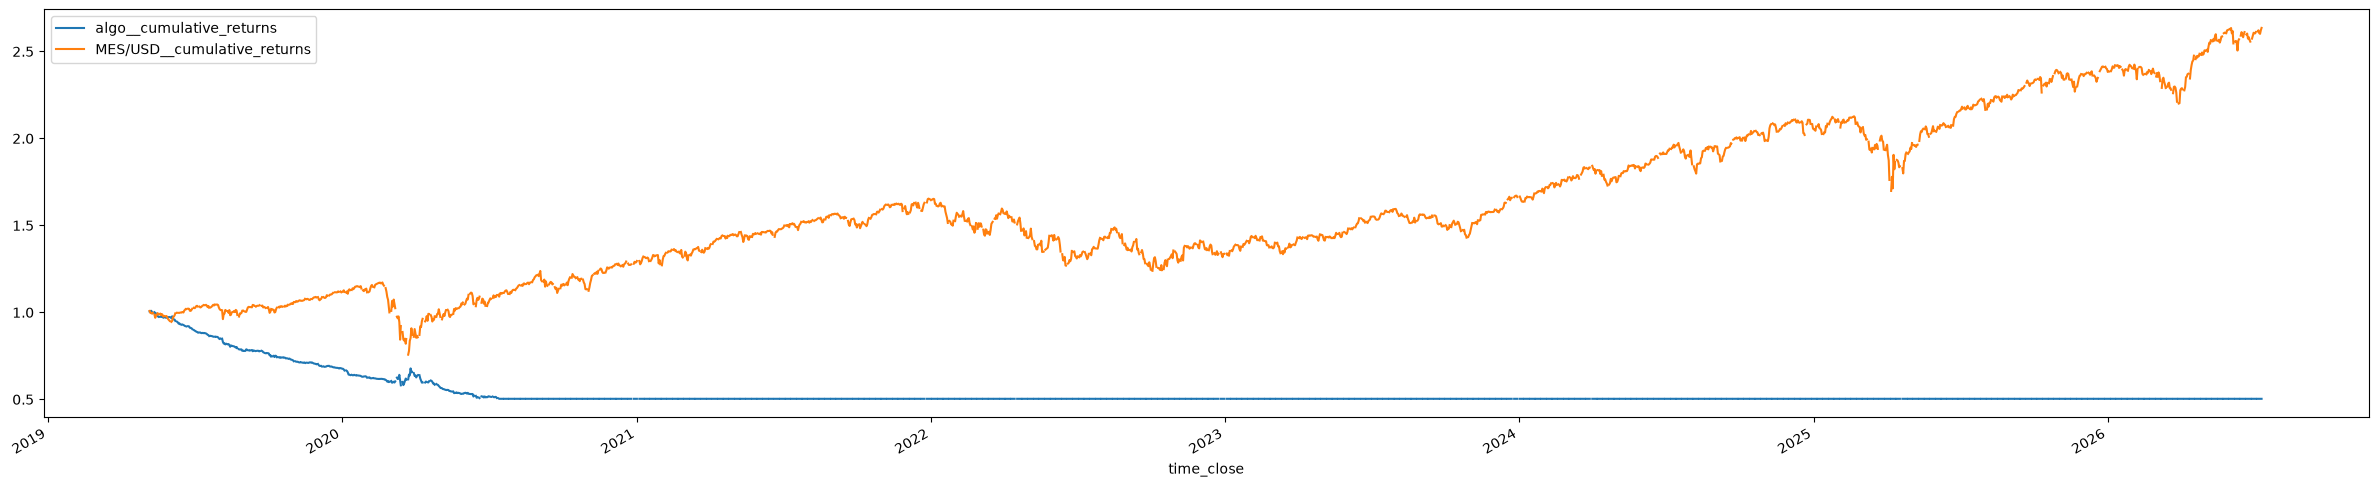

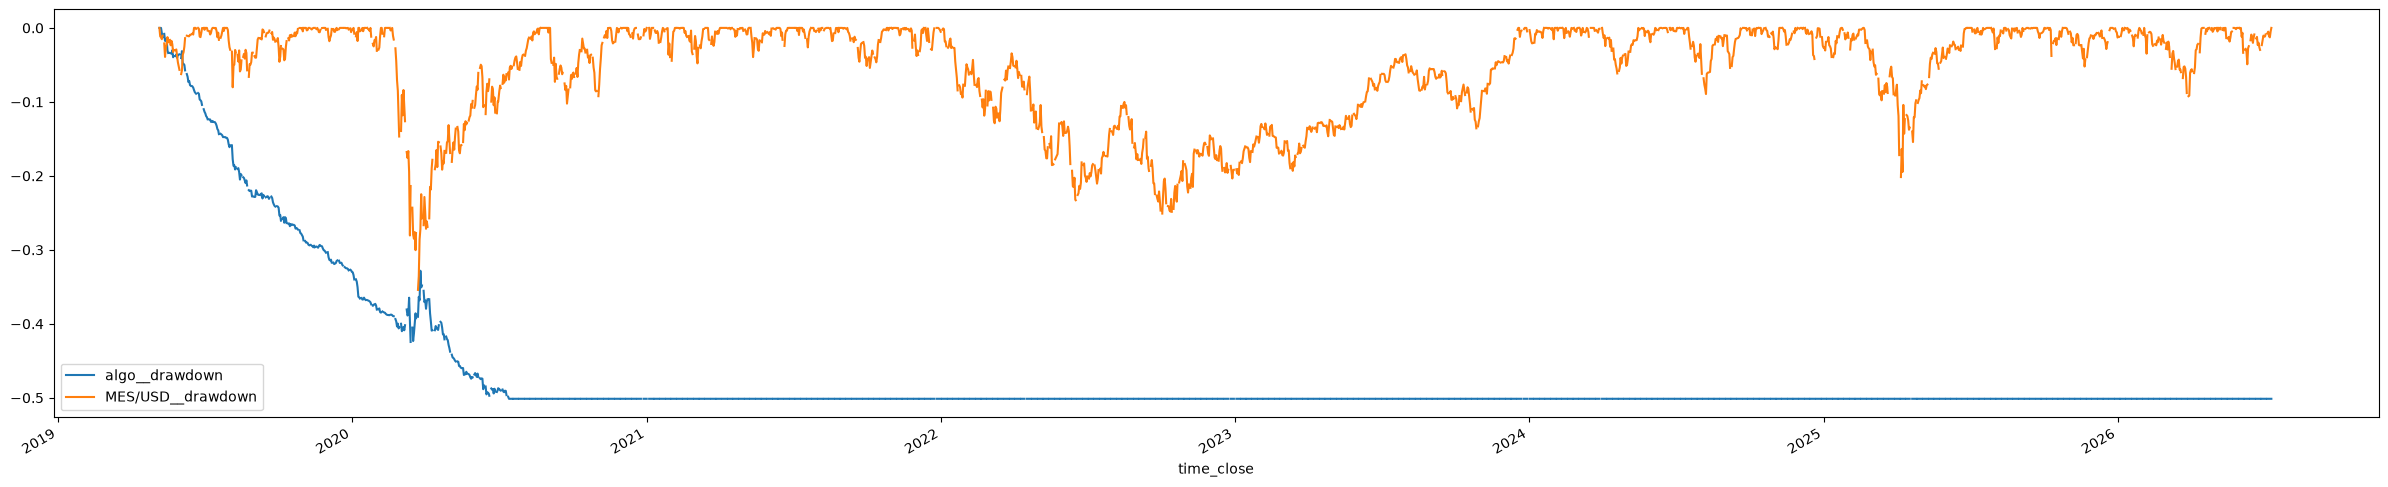

In [5]:
best_entry_std, best_sl_percent = grid_results.iloc[0][["entry_std", "sl_percent"]]
best_entry_std = float(best_entry_std)
best_sl_percent = float(best_sl_percent)
print(f"Best combo: entry_std={best_entry_std}, sl_percent={best_sl_percent}")
best_backtest, best_drawdown_mw = grid_backtests[(best_entry_std, best_sl_percent)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Holdout check: does the best combo survive a train/test split?


In [6]:
split_idx = int(len(ohlc) * 0.75)
split_date = ohlc.index[split_idx]
print(f"train/test split at {split_date}  ({split_idx} train bars, {len(ohlc) - split_idx} test bars)")

train_ohlc, test_ohlc = ohlc.loc[:split_date], ohlc.loc[split_date:]


def trade_sharpe_lb(trades: list, z: float = 1.645) -> tuple[float, float, int]:
    '''Lo (2002) Sharpe lower bound over a strategy's per-trade returns: point
    estimate minus z standard errors, SE(SR) ~= sqrt((1 + SR^2/2) / N). Returns
    (trade_sharpe, trade_sharpe_lb, n) -- NaN Sharpes if fewer than 2 trades or a
    zero-variance trade set (can't estimate a standard error from either).'''
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


holdout_rows = []
for label, ohlc_slice in [
    ("FULL", ohlc),
    ("TRAIN (75%)", train_ohlc),
    ("TEST (last 25%, unseen)", test_ohlc),
]:
    bt, drawdown_mw = run_vwap_mr_backtest(ohlc_slice, best_entry_std, best_sl_percent, key=f"VWAPMR_holdout_{label}")
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    holdout_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
    })

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
print(holdout_df.to_string())


train/test split at 2024-09-24 02:44:59.999000  (126208 train bars, 42070 test bars)


                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
window                                                                                                                                                                                             
FULL                       2290         73.493450     -0.022268        -0.056648       -1.165149          -49.677320              0.786255          -7.483664              -50.1390            True
TRAIN (75%)                2290         73.493450     -0.022268        -0.056648       -1.346436          -49.677320              0.786255          -7.483664              -50.1390            True
TEST (last 25%, unseen)    3788         78.141499      0.026100        -0.000632       -1.754950          -31.750923              0.872558          -3.083852              -31.7884           False


## Findings

**Decisively negative -- the worst grid in this pipeline, and the first
strategy where most combos actually breach the drawdown middleware rather
than just underperforming.** All 16 (`entry_std`, `sl_percent`) combos are
net-negative (Sharpe -1.17 to -1.74), and **13 of 16 breach the 50%-loosened
Tradeify drawdown middleware** (`account_failed=True`) -- the real limit is
4%, so every one of these would have blown the account many times over.

**Best combo (`entry_std=1.5, sl_percent=0.015`)**: FULL net return -49.7%,
Sharpe -1.17, `dollar_profit_factor` 0.79, and it *still* breaches the
drawdown middleware. There is no combo in this grid that would have survived
even this repo's loosened risk limits, let alone a real one.

**The classic mean-reversion trap, visible directly in the numbers**: win
rates are high across the board (62-83%, vs. 33-38% for every trend-following
strategy in this pipeline) but expectancy is negative anyway --
`dollar_profit_factor` sits below 1.0 for the large majority of combos
despite those high win rates. Wins are small (reversion back to VWAP is
usually a modest move), but losses are large whenever price keeps extending
past the stop instead of reverting -- exactly the "picking up nickels in
front of a steamroller" failure mode mean-reversion strategies are known for.

**Root cause, tied directly to this pipeline's own strongest finding**: this
strategy trades `direction=both` -- fading extensions in *either* direction,
including shorting apparent overextensions during genuine uptrend
continuation. Every trend-following strategy in this pipeline has found a
real (if modest) long-only edge on MES/MNQ specifically *because* of their
2019-2026 bull drift -- a both-direction fade strategy is structurally on the
wrong side of that same drift every time it shorts a real breakout rather
than a genuine exhaustion, and MES/MNQ trend hard enough, often enough, that
this dominates the strategy's economics.

**A data artifact worth flagging**: the holdout table shows TRAIN's numbers
*exactly* matching FULL's (same trade count, same win rate, same return to 6
decimal places) -- not a bug, but a real consequence of the drawdown
middleware: the FULL-period run breaches the 50% drawdown limit early enough
that trading halts for the remainder of the series, so the FULL run's entire
trade history is identical to the TRAIN-only run's. The TEST-only run (a
fresh backtest starting mid-series with its own new deposit) shows different,
somewhat-less-bad numbers (-31.8% net, no drawdown breach) simply because it
starts after whatever regime caused the earlier blowup, not because the
strategy is TEST-period-specific -- both windows are still solidly negative.

**Bottom line**: VWAP deviation-band mean-reversion, both-direction, does not
show a real edge on MES 15m -- not "not yet confirmed," but decisively
negative with real account-destroying tail risk in most of the grid. Not
running walk-forward (nothing promising to confirm) or extending to MNQ/M2K
(the failure is mechanism-level, not a symbol-specific quirk, and the same
root cause -- fighting this pipeline's own established long-only trend
edge -- would apply to MNQ even more since MNQ trends harder than MES in this
dataset). If mean-reversion is worth revisiting, the natural next iteration
is fading only *against* the prevailing trend direction less aggressively --
e.g. `direction=long` only (fade dips, never fade rallies) with a trend
regime filter, similar in spirit to the long-only fix that rescued every
trend-following strategy in this pipeline -- rather than more grid search on
the current both-direction construction.